In [ ]:
!pip install -q tensorflow opencv-python split-folders seaborn

In [ ]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tensorflow as tf

from google.colab import drive, files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = '/content/drive/MyDrive/project1'   # your original dataset folder
flat_dir = '/content/flat_data'
split_dir = '/content/data_split'
model_save_path = '/content/drive/MyDrive/ayurvedic_fast_model.keras'

In [ ]:
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def flatten_dataset(src, dst):
    if not os.path.exists(src):
        raise FileNotFoundError(f"Source path not found: {src}")

    if os.path.exists(dst):
        shutil.rmtree(dst)
    os.makedirs(dst, exist_ok=True)

    for plant in os.listdir(src):
        plant_path = os.path.join(src, plant)
        if not os.path.isdir(plant_path):
            continue

        for item in os.listdir(plant_path):
            item_path = os.path.join(plant_path, item)
            if not os.path.isdir(item_path):
                continue

            item_lower = item.lower().strip()

            # Healthy folder
            if "healthy" in item_lower:
                class_name = f"{plant}___Healthy"
                class_dir = os.path.join(dst, class_name)
                os.makedirs(class_dir, exist_ok=True)

                for fname in os.listdir(item_path):
                    fpath = os.path.join(item_path, fname)
                    if os.path.isfile(fpath) and fname.lower().endswith(IMAGE_EXTS):
                        shutil.copy2(fpath, os.path.join(class_dir, fname))

            else:
                # Case 1: disease images directly inside folder
                direct_images = [
                    f for f in os.listdir(item_path)
                    if os.path.isfile(os.path.join(item_path, f)) and f.lower().endswith(IMAGE_EXTS)
                ]

                if direct_images:
                    class_name = f"{plant}___{item.replace(' ', '_')}"
                    class_dir = os.path.join(dst, class_name)
                    os.makedirs(class_dir, exist_ok=True)

                    for fname in direct_images:
                        fpath = os.path.join(item_path, fname)
                        shutil.copy2(fpath, os.path.join(class_dir, fname))

                else:
                    # Case 2: disease folder contains subfolders
                    for disease in os.listdir(item_path):
                        disease_path = os.path.join(item_path, disease)
                        if not os.path.isdir(disease_path):
                            continue

                        class_name = f"{plant}___{disease.replace(' ', '_')}"
                        class_dir = os.path.join(dst, class_name)
                        os.makedirs(class_dir, exist_ok=True)

                        for fname in os.listdir(disease_path):
                            fpath = os.path.join(disease_path, fname)
                            if os.path.isfile(fpath) and fname.lower().endswith(IMAGE_EXTS):
                                shutil.copy2(fpath, os.path.join(class_dir, fname))

    print("Flattening completed.")
    print("Classes created:", os.listdir(dst))

In [ ]:
flatten_dataset(base_dir, flat_dir)

for cls in os.listdir(flat_dir):
    cls_path = os.path.join(flat_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)), "images")

Flattening completed.
Classes created: ['Neem___Defoliator', 'turmeric___Dry_Leaf', 'Aloe vera___Leaf_Spot', 'tulsi___Healthy', 'turmeric___Leaf_Blotch', 'Neem___Irregular_yellowing', 'Neem___Healthy', 'Aloe vera___Healthy', 'tulsi___Bacterial', 'turmeric___Healthy', 'Aloe vera___Anthracnose', 'Neem___Leaf_blotch', 'tulsi___Fungal', 'Aloe vera___Aloe_Rust', 'Neem___Dieback', 'tulsi___Pests', 'Aloe vera___Sunburn', 'Neem___Bacterial_infection']
Neem___Defoliator -> 1559 images
turmeric___Dry_Leaf -> 203 images
Aloe vera___Leaf_Spot -> 500 images
tulsi___Healthy -> 611 images
turmeric___Leaf_Blotch -> 199 images
Neem___Irregular_yellowing -> 1152 images
Neem___Healthy -> 1821 images
Aloe vera___Healthy -> 780 images
tulsi___Bacterial -> 163 images
turmeric___Healthy -> 197 images
Aloe vera___Anthracnose -> 500 images
Neem___Leaf_blotch -> 1336 images
tulsi___Fungal -> 392 images
Aloe vera___Aloe_Rust -> 210 images
Neem___Dieback -> 1859 images
tulsi___Pests -> 652 images
Aloe vera___Sunb

In [ ]:
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

splitfolders.ratio(flat_dir, output=split_dir, seed=42, ratio=(0.7, 0.2, 0.1))

print("Split folders:", os.listdir(split_dir))
print("Train classes:", os.listdir(os.path.join(split_dir, 'train')))
print("Val classes:", os.listdir(os.path.join(split_dir, 'val')))
print("Test classes:", os.listdir(os.path.join(split_dir, 'test')))

Copying files: 13460 files [00:07, 1782.35 files/s]

Split folders: ['test', 'train', 'val']
Train classes: ['Neem___Defoliator', 'turmeric___Dry_Leaf', 'Aloe vera___Leaf_Spot', 'tulsi___Healthy', 'turmeric___Leaf_Blotch', 'Neem___Irregular_yellowing', 'Neem___Healthy', 'Aloe vera___Healthy', 'tulsi___Bacterial', 'turmeric___Healthy', 'Aloe vera___Anthracnose', 'Neem___Leaf_blotch', 'tulsi___Fungal', 'Aloe vera___Aloe_Rust', 'Neem___Dieback', 'tulsi___Pests', 'Aloe vera___Sunburn', 'Neem___Bacterial_infection']
Val classes: ['Neem___Defoliator', 'turmeric___Dry_Leaf', 'Aloe vera___Leaf_Spot', 'tulsi___Healthy', 'turmeric___Leaf_Blotch', 'Neem___Irregular_yellowing', 'Neem___Healthy', 'Aloe vera___Healthy', 'tulsi___Bacterial', 'turmeric___Healthy', 'Aloe vera___Anthracnose', 'Neem___Leaf_blotch', 'tulsi___Fungal', 'Aloe vera___Aloe_Rust', 'Neem___Dieback', 'tulsi___Pests', 'Aloe vera___Sunburn', 'Neem___Bacterial_infection']
Test classes: ['Neem___Defoliator', 'turmeric___Dry_Leaf', 'Aloe vera___Leaf_Spot', 'tulsi___Healthy', 'turmeric__

In [ ]:
train_dir = os.path.join(split_dir, 'train')
val_dir = os.path.join(split_dir, 'val')
test_dir = os.path.join(split_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_gen = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_gen.class_indices)
print("Number of classes:", len(train_gen.class_indices))

Found 9417 images belonging to 18 classes.
Found 2686 images belonging to 18 classes.
Found 1357 images belonging to 18 classes.
Classes: {'Aloe vera___Aloe_Rust': 0, 'Aloe vera___Anthracnose': 1, 'Aloe vera___Healthy': 2, 'Aloe vera___Leaf_Spot': 3, 'Aloe vera___Sunburn': 4, 'Neem___Bacterial_infection': 5, 'Neem___Defoliator': 6, 'Neem___Dieback': 7, 'Neem___Healthy': 8, 'Neem___Irregular_yellowing': 9, 'Neem___Leaf_blotch': 10, 'tulsi___Bacterial': 11, 'tulsi___Fungal': 12, 'tulsi___Healthy': 13, 'tulsi___Pests': 14, 'turmeric___Dry_Leaf': 15, 'turmeric___Healthy': 16, 'turmeric___Leaf_Blotch': 17}
Number of classes: 18


In [ ]:
tf.keras.backend.clear_session()

num_classes = len(train_gen.class_indices)

inputs = Input(shape=(224, 224, 3))

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_1493/413081856.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,424,274 (9.25 MB)

 Trainable params: 166,290 (649.57 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint('/content/ayurvedic_fast_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True,
                    verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/10
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.4458 - loss: 1.9057
Epoch 1: val_accuracy improved from None to 0.81124, saving model to /content/ayurvedic_fast_model.keras

Epoch 1: finished saving model to /content/ayurvedic_fast_model.keras
589/589 ━━━━━━━━━━━━━━━━━━━━ 230s 358ms/step - accuracy: 0.5970 - loss: 1.3258 - val_accuracy: 0.8112 - val_loss: 0.6245 - learning_rate: 1.0000e-04
Epoch 2/10
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.7756 - loss: 0.6999
Epoch 2: val_accuracy improved from 0.81124 to 0.85853, saving model to /content/ayurvedic_fast_model.keras

Epoch 2: finished saving model to /content/ayurvedic_fast_model.keras
589/589 ━━━━━━━━━━━━━━━━━━━━ 184s 312ms/step - accuracy: 0.7885 - loss: 0.6535 - val_accuracy: 0.8585 - val_loss: 0.4440 - learning_rate: 1.0000e-04
Epoch 3/10
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8327 - loss: 0.5114
Epoch 3: val_accuracy improved from 0.85853 to 0.87789, saving model to /content/ay

In [ ]:
model.save(model_save_path)
print("Model saved to:", model_save_path)

Model saved to: /content/drive/MyDrive/ayurvedic_fast_model.keras


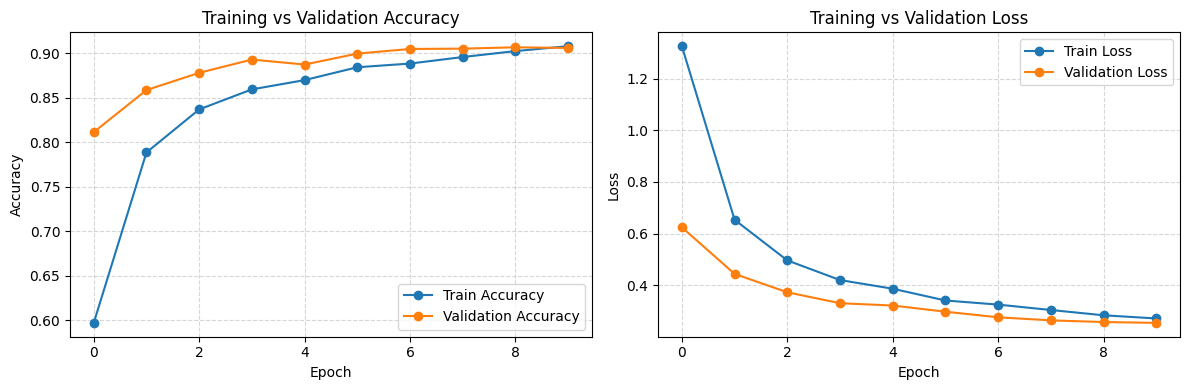

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes
labels = list(test_gen.class_indices.keys())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=labels))

85/85 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step
Test Accuracy: 0.9012527634487841
                            precision    recall  f1-score   support

     Aloe vera___Aloe_Rust       0.50      0.10      0.16        21
   Aloe vera___Anthracnose       0.57      0.78      0.66        50
       Aloe vera___Healthy       0.75      0.63      0.69        78
     Aloe vera___Leaf_Spot       0.42      0.52      0.46        50
       Aloe vera___Sunburn       0.53      0.51      0.52        51
Neem___Bacterial_infection       0.96      0.84      0.90        82
         Neem___Defoliator       0.99      1.00      1.00       157
            Neem___Dieback       1.00      1.00      1.00       187
            Neem___Healthy       0.94      0.98      0.96       183
Neem___Irregular_yellowing       0.94      0.97      0.96       116
        Neem___Leaf_blotch       0.98      0.96      0.97       134
         tulsi___Bacterial       1.00      1.00      1.00        17
            tulsi___Fungal       1.00  

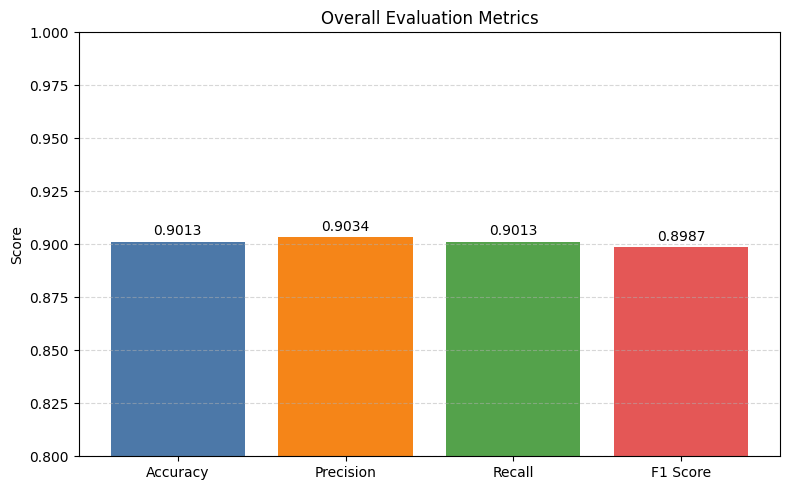

In [ ]:
plt.figure(figsize=(8, 5))

colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

plt.bar(metrics_df["Metric"], metrics_df["Score"], color=colors)

plt.ylim(0.80, 1.00)   # zoomed range to show small differences clearly
plt.title("Overall Evaluation Metrics")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, score in enumerate(metrics_df["Score"]):
    plt.text(i, score + 0.003, f"{score:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

acc = accuracy_score(y_true, y_pred)
prec_weighted = precision_score(y_true, y_pred, average='weighted')
rec_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

print("========== MODEL PERFORMANCE ==========")
print(f"Accuracy            : {acc:.4f}")
print(f"Weighted Precision  : {prec_weighted:.4f}")
print(f"Weighted Recall     : {rec_weighted:.4f}")
print(f"Weighted F1 Score   : {f1_weighted:.4f}")
print(f"Macro Precision     : {prec_macro:.4f}")
print(f"Macro Recall        : {rec_macro:.4f}")
print(f"Macro F1 Score      : {f1_macro:.4f}")
print("=======================================")

========== MODEL PERFORMANCE ==========
Accuracy            : 0.9013
Weighted Precision  : 0.9034
Weighted Recall     : 0.9013
Weighted F1 Score   : 0.8987
Macro Precision     : 0.8645
Macro Recall        : 0.8468
Macro F1 Score      : 0.8461


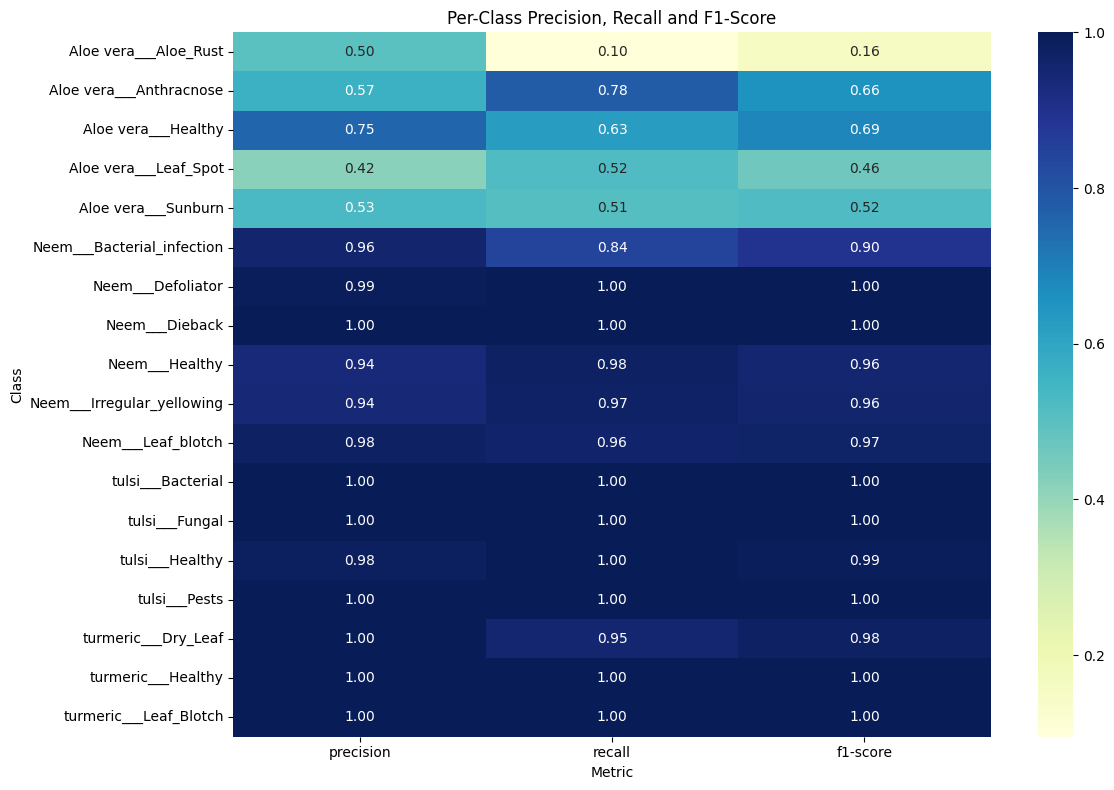

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
class_report_df = pd.DataFrame(report_dict).transpose()

class_metrics_df = class_report_df.iloc[:len(labels)][["precision", "recall", "f1-score"]]

plt.figure(figsize=(12, 8))
sns.heatmap(class_metrics_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Per-Class Precision, Recall and F1-Score")
plt.xlabel("Metric")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

In [ ]:
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes

85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step


/tmp/ipykernel_1493/308780236.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([correct_conf, incorrect_conf], labels=["Correct Predictions", "Incorrect Predictions"])


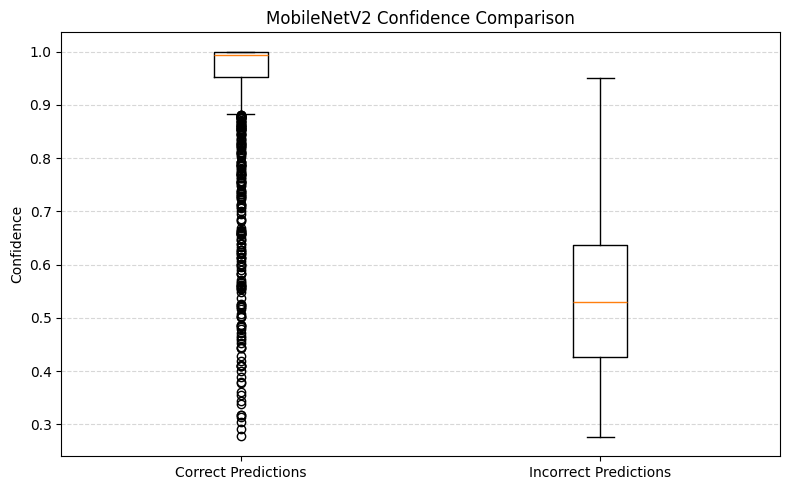

Mean confidence (Correct Predictions)  : 0.934
Mean confidence (Incorrect Predictions): 0.552
Max confidence (Correct Predictions)   : 1.0
Max confidence (Incorrect Predictions) : 0.9508
Min confidence (Correct Predictions)   : 0.2771
Min confidence (Incorrect Predictions) : 0.2761


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# confidence scores from model output
y_conf = np.max(pred, axis=1)

# separate correct and incorrect predictions
correct_mask = (y_pred == y_true)
correct_conf = y_conf[correct_mask]
incorrect_conf = y_conf[~correct_mask]

# boxplot comparison
plt.figure(figsize=(8, 5))
plt.boxplot([correct_conf, incorrect_conf], labels=["Correct Predictions", "Incorrect Predictions"])
plt.title("MobileNetV2 Confidence Comparison")
plt.ylabel("Confidence")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Mean confidence (Correct Predictions)  :", round(float(np.mean(correct_conf)), 4))
print("Mean confidence (Incorrect Predictions):", round(float(np.mean(incorrect_conf)), 4))
print("Max confidence (Correct Predictions)   :", round(float(np.max(correct_conf)), 4))
print("Max confidence (Incorrect Predictions) :", round(float(np.max(incorrect_conf)), 4))
print("Min confidence (Correct Predictions)   :", round(float(np.min(correct_conf)), 4))
print("Min confidence (Incorrect Predictions) :", round(float(np.min(incorrect_conf)), 4))

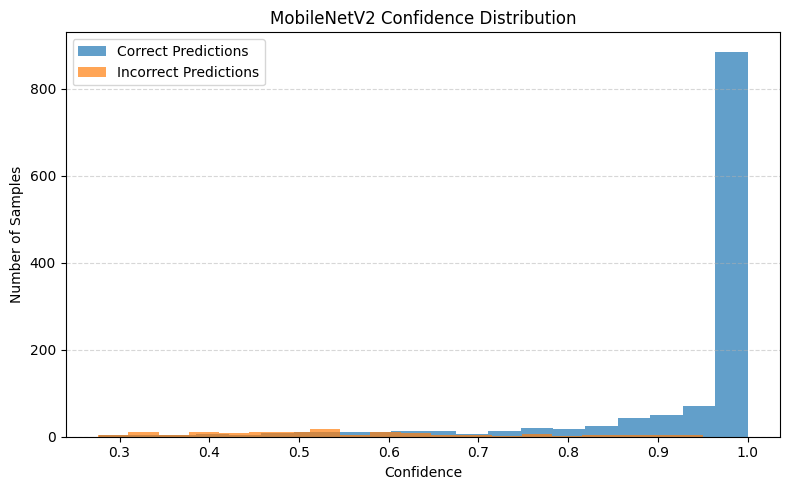

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(correct_conf, bins=20, alpha=0.7, label='Correct Predictions')
plt.hist(incorrect_conf, bins=20, alpha=0.7, label='Incorrect Predictions')
plt.title("MobileNetV2 Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

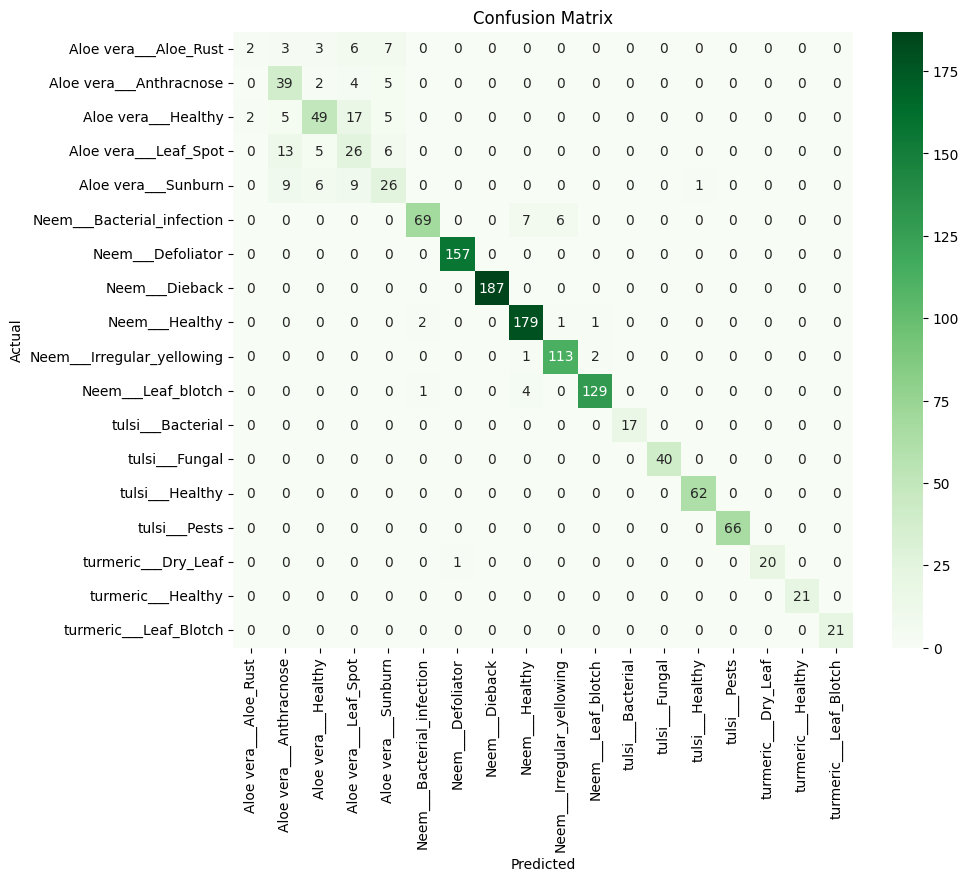

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))


Detailed Classification Report:

                            precision    recall  f1-score   support

     Aloe vera___Aloe_Rust       0.50      0.10      0.16        21
   Aloe vera___Anthracnose       0.57      0.78      0.66        50
       Aloe vera___Healthy       0.75      0.63      0.69        78
     Aloe vera___Leaf_Spot       0.42      0.52      0.46        50
       Aloe vera___Sunburn       0.53      0.51      0.52        51
Neem___Bacterial_infection       0.96      0.84      0.90        82
         Neem___Defoliator       0.99      1.00      1.00       157
            Neem___Dieback       1.00      1.00      1.00       187
            Neem___Healthy       0.94      0.98      0.96       183
Neem___Irregular_yellowing       0.94      0.97      0.96       116
        Neem___Leaf_blotch       0.98      0.96      0.97       134
         tulsi___Bacterial       1.00      1.00      1.00        17
            tulsi___Fungal       1.00      1.00      1.00        40
           tu

In [ ]:
def enhance_image(img):
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    return img_rgb, enhanced

Saving Dry Leaf00004.JPG to Dry Leaf00004.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


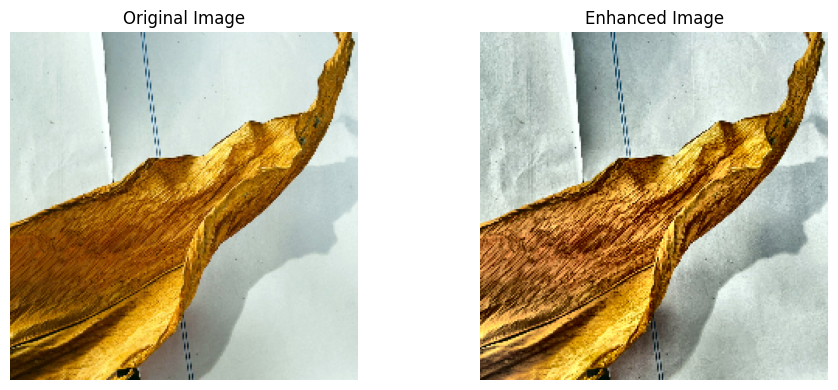

Predicted Class: turmeric___Dry_Leaf
Confidence: 0.9833


In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
orig, enhanced = enhance_image(img)

input_img = enhanced.astype(np.float32) / 255.0
input_img = np.expand_dims(input_img, axis=0)

pred = model.predict(input_img)
class_id = np.argmax(pred)
confidence = np.max(pred)

class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[class_id]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(float(confidence), 4))

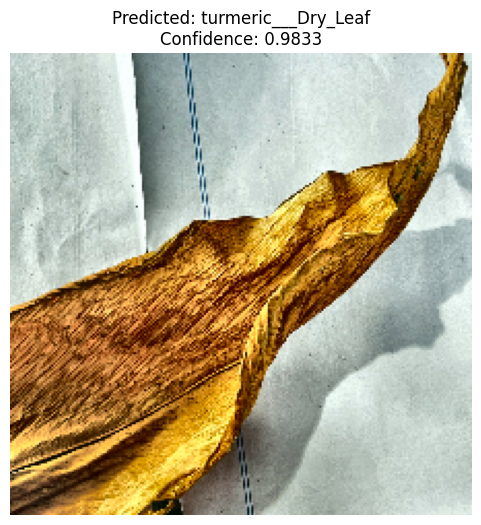

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(enhanced)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.4f}")
plt.axis("off")
plt.show()

In [ ]:
bg_mask, bg_removed = remove_background(enhanced)
lesion_mask, lesion = segment_lesion(bg_removed)

In [ ]:
def remove_background(enhanced_img):
    gray = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2GRAY)

    # threshold for leaf vs background
    _, bg_mask = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

    # clean mask
    kernel = np.ones((3, 3), np.uint8)
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_OPEN, kernel)
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_CLOSE, kernel)

    bg_removed = cv2.bitwise_and(enhanced_img, enhanced_img, mask=bg_mask)
    return bg_mask, bg_removed


def segment_lesion(bg_removed_img):
    hsv = cv2.cvtColor(bg_removed_img, cv2.COLOR_RGB2HSV)

    # tune these if needed for your leaf images
    lower = np.array([10, 30, 30])
    upper = np.array([35, 255, 255])

    lesion_mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((3, 3), np.uint8)
    lesion_mask = cv2.morphologyEx(lesion_mask, cv2.MORPH_OPEN, kernel)
    lesion_mask = cv2.morphologyEx(lesion_mask, cv2.MORPH_CLOSE, kernel)

    lesion = cv2.bitwise_and(bg_removed_img, bg_removed_img, mask=lesion_mask)
    return lesion_mask, lesion

In [ ]:
import cv2
import numpy as np

def extract_leaf_color_stats(rgb_img):
    # RGB means
    mean_r = np.mean(rgb_img[:, :, 0])
    mean_g = np.mean(rgb_img[:, :, 1])
    mean_b = np.mean(rgb_img[:, :, 2])

    # HSV stats
    hsv = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)
    mean_h = np.mean(hsv[:, :, 0])
    mean_s = np.mean(hsv[:, :, 1])
    mean_v = np.mean(hsv[:, :, 2])

    # Greenness index
    greenness = mean_g - (mean_r + mean_b) / 2

    stats = {
        "mean_red": round(float(mean_r), 2),
        "mean_green": round(float(mean_g), 2),
        "mean_blue": round(float(mean_b), 2),
        "mean_hue": round(float(mean_h), 2),
        "mean_saturation": round(float(mean_s), 2),
        "mean_value": round(float(mean_v), 2),
        "greenness_index": round(float(greenness), 2)
    }

    return stats

In [ ]:
# Manual input values for advanced project extension
temperature = 32.5       # in degree Celsius
humidity = 68.0          # in percentage
soil_moisture = 42.0     # in percentage
environment_condition = "Outdoor / Natural Daylight"

In [ ]:
def interpret_environment(temperature, humidity, soil_moisture):
    remarks = []

    if temperature > 35:
        remarks.append("High temperature may stress the plant.")
    elif temperature < 18:
        remarks.append("Low temperature may slow plant growth.")
    else:
        remarks.append("Temperature is within a moderate range.")

    if humidity > 80:
        remarks.append("High humidity may increase fungal disease risk.")
    elif humidity < 35:
        remarks.append("Low humidity may lead to dryness stress.")
    else:
        remarks.append("Humidity is within an acceptable range.")

    if soil_moisture > 75:
        remarks.append("Soil moisture is high; overwatering risk may be present.")
    elif soil_moisture < 25:
        remarks.append("Soil moisture is low; plant may need watering.")
    else:
        remarks.append("Soil moisture appears balanced.")

    return remarks

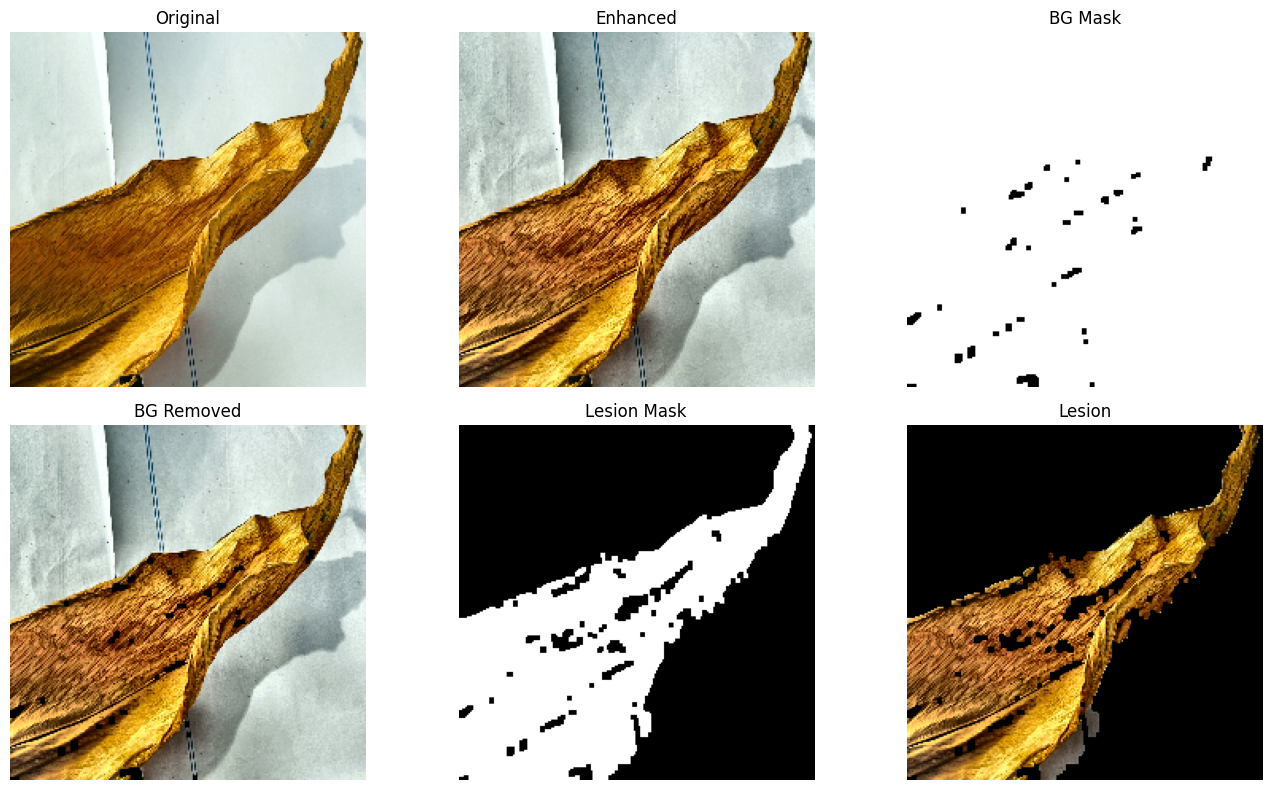

In [ ]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(enhanced)
plt.title("Enhanced")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(bg_mask, cmap='gray')
plt.title("BG Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bg_removed)
plt.title("BG Removed")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(lesion_mask, cmap='gray')
plt.title("Lesion Mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(lesion)
plt.title("Lesion")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [ ]:
for layer in reversed(model.layers):
    try:
        if len(layer.output.shape) == 4:
            print(layer.name, layer.output.shape)
    except:
        pass

out_relu (None, 7, 7, 1280)
Conv_1_bn (None, 7, 7, 1280)
Conv_1 (None, 7, 7, 1280)
block_16_project_BN (None, 7, 7, 320)
block_16_project (None, 7, 7, 320)
block_16_depthwise_relu (None, 7, 7, 960)
block_16_depthwise_BN (None, 7, 7, 960)
block_16_depthwise (None, 7, 7, 960)
block_16_expand_relu (None, 7, 7, 960)
block_16_expand_BN (None, 7, 7, 960)
block_16_expand (None, 7, 7, 960)
block_15_add (None, 7, 7, 160)
block_15_project_BN (None, 7, 7, 160)
block_15_project (None, 7, 7, 160)
block_15_depthwise_relu (None, 7, 7, 960)
block_15_depthwise_BN (None, 7, 7, 960)
block_15_depthwise (None, 7, 7, 960)
block_15_expand_relu (None, 7, 7, 960)
block_15_expand_BN (None, 7, 7, 960)
block_15_expand (None, 7, 7, 960)
block_14_add (None, 7, 7, 160)
block_14_project_BN (None, 7, 7, 160)
block_14_project (None, 7, 7, 160)
block_14_depthwise_relu (None, 7, 7, 960)
block_14_depthwise_BN (None, 7, 7, 960)
block_14_depthwise (None, 7, 7, 960)
block_14_expand_relu (None, 7, 7, 960)
block_14_expand_BN (

In [ ]:
last_conv_layer_name = "out_relu"

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


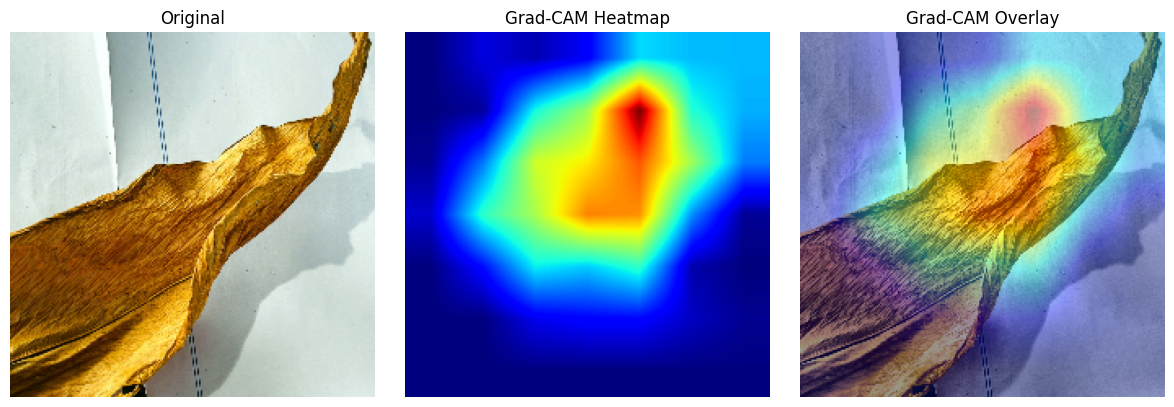

In [ ]:
heatmap = make_gradcam_heatmap(input_img, model, last_conv_layer_name)

heatmap = cv2.resize(heatmap, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(
    cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap_color,
    0.4,
    0
)

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_rgb)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

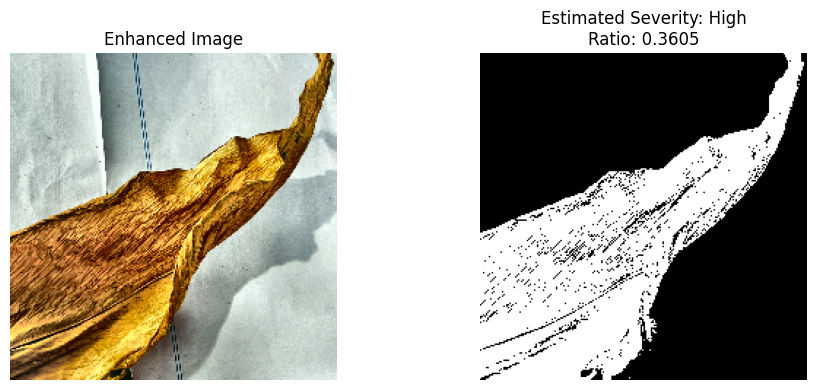

Severity: High
Severity Ratio: 0.3605


In [ ]:
def simple_severity(enhanced_img):
    hsv = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2HSV)

    lower = np.array([10, 40, 40])
    upper = np.array([35, 255, 255])

    lesion_mask = cv2.inRange(hsv, lower, upper)
    infected_pixels = np.sum(lesion_mask > 0)
    total_pixels = lesion_mask.size
    ratio = infected_pixels / total_pixels

    if ratio < 0.1:
        severity = "Low"
    elif ratio < 0.3:
        severity = "Medium"
    else:
        severity = "High"

    return lesion_mask, ratio, severity

lesion_mask, ratio, severity = simple_severity(enhanced)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(enhanced)
plt.title("Enhanced Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lesion_mask, cmap='gray')
plt.title(f"Estimated Severity: {severity}\nRatio: {ratio:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Severity:", severity)
print("Severity Ratio:", round(float(ratio), 4))

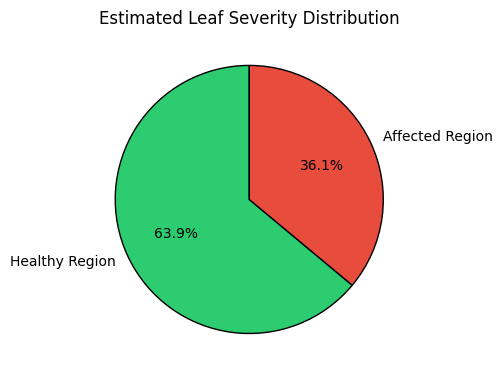

In [ ]:
healthy_part = 1 - ratio
infected_part = ratio

plt.figure(figsize=(5, 5))
plt.pie(
    [healthy_part, infected_part],
    labels=["Healthy Region", "Affected Region"],
    colors=["#2ECC71", "#E74C3C"],   # green and red
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)
plt.title("Estimated Leaf Severity Distribution")
plt.tight_layout()
plt.show()

In [ ]:
leaf_stats = extract_leaf_color_stats(enhanced)
env_remarks = interpret_environment(temperature, humidity, soil_moisture)

print("Leaf Color Statistics:")
for k, v in leaf_stats.items():
    print(f"{k}: {v}")

print("\nEnvironmental Parameters:")
print("Temperature     :", temperature, "°C")
print("Humidity        :", humidity, "%")
print("Soil Moisture   :", soil_moisture, "%")
print("Environment     :", environment_condition)

print("\nEnvironmental Remarks:")
for r in env_remarks:
    print("-", r)

Leaf Color Statistics:
mean_red: 174.27
mean_green: 161.62
mean_blue: 129.82
mean_hue: 52.24
mean_saturation: 95.42
mean_value: 182.48
greenness_index: 9.58

Environmental Parameters:
Temperature     : 32.5 °C
Humidity        : 68.0 %
Soil Moisture   : 42.0 %
Environment     : Outdoor / Natural Daylight

Environmental Remarks:
- Temperature is within a moderate range.
- Humidity is within an acceptable range.
- Soil moisture appears balanced.


In [ ]:
def get_suggestion(predicted_class, confidence, severity):
    disease_name = predicted_class.split("___")[-1].lower()

    if confidence < 0.50:
        return "Prediction confidence is low. Please upload a clearer leaf image under better lighting."

    if "healthy" in disease_name:
        return "The leaf appears healthy. Maintain regular watering, proper sunlight, and routine monitoring."

    # Neem suggestions
    if "neem" in predicted_class.lower():
        if severity == "Low":
            return "Early symptoms detected in Neem. Remove mildly affected leaves and monitor the plant regularly."
        elif severity == "Medium":
            return "Neem leaf disease appears moderate. Remove infected leaves and apply suitable organic antifungal treatment."
        else:
            return "Severe Neem infection detected. Isolate the plant, remove heavily affected leaves, and start immediate treatment."

    # Tulsi suggestions
    if "tulsi" in predicted_class.lower():
        if severity == "Low":
            return "Minor Tulsi infection detected. Improve airflow and avoid overwatering."
        elif severity == "Medium":
            return "Moderate Tulsi disease detected. Remove affected leaves and apply a mild organic fungicide."
        else:
            return "Severe Tulsi disease detected. Immediate care is needed. Prune infected portions and inspect nearby plants."

    # Aloe Vera suggestions
    if "aloe" in predicted_class.lower():
        if severity == "Low":
            return "Mild Aloe Vera stress or disease symptoms detected. Avoid excess watering and monitor leaf condition."
        elif severity == "Medium":
            return "Moderate Aloe Vera infection detected. Remove damaged tissue and keep the plant in a dry, ventilated place."
        else:
            return "Severe Aloe Vera damage detected. Reduce watering, isolate the plant, and begin treatment quickly."

    # Turmeric suggestions
    if "turmeric" in predicted_class.lower():
        if severity == "Low":
            return "Mild Turmeric leaf symptoms detected. Continue observation and maintain balanced moisture."
        elif severity == "Medium":
            return "Moderate Turmeric leaf infection detected. Remove infected leaves and apply suitable treatment."
        else:
            return "Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread."

    # Generic fallback
    if severity == "Low":
        return "Mild disease symptoms detected. Monitor the plant and remove slightly affected leaves."
    elif severity == "Medium":
        return "Moderate disease symptoms detected. Remove infected leaves and apply appropriate plant care."
    else:
        return "Severe disease symptoms detected. Immediate treatment and isolation of the plant are recommended."

In [ ]:
suggestion = get_suggestion(predicted_class, confidence, severity)

print("\n====== FINAL DIAGNOSIS REPORT ======")
print("Predicted Disease :", predicted_class)
print("Confidence        :", round(float(confidence) * 100, 2), "%")
print("Severity          :", severity)
print("Suggestion        :", suggestion)


====== FINAL DIAGNOSIS REPORT ======
Predicted Disease : turmeric___Dry_Leaf
Confidence        : 98.33 %
Severity          : High
Suggestion        : Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread.


In [ ]:
lesion_mask, ratio, severity = simple_severity(enhanced)
suggestion = get_suggestion(predicted_class, confidence, severity)

print("\n====== FINAL DIAGNOSIS REPORT ======")
print("Predicted Disease :", predicted_class)
print("Confidence        :", round(float(confidence) * 100, 2), "%")
print("Severity          :", severity)
print("Severity Ratio    :", round(float(ratio), 4))
print("Suggestion        :", suggestion)


====== FINAL DIAGNOSIS REPORT ======
Predicted Disease : turmeric___Dry_Leaf
Confidence        : 98.33 %
Severity          : High
Severity Ratio    : 0.3605
Suggestion        : Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread.


In [ ]:
import numpy as np
import cv2

def field_support_checks(img_bgr, confidence, min_size=(224, 224), dark_threshold=60, blur_threshold=80):
    issues = []
    h, w = img_bgr.shape[:2]

    if w < min_size[0] or h < min_size[1]:
        issues.append("Low resolution image")

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    if brightness < dark_threshold:
        issues.append("Poor lighting detected")

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    if blur_score < blur_threshold:
        issues.append("Blur detected")

    if confidence < 0.50:
        issues.append("Prediction confidence is low")

    if len(issues) == 0:
        status = "Suitable for diagnosis"
    else:
        status = "Image may reduce prediction reliability"

    return status, issues, brightness, blur_score

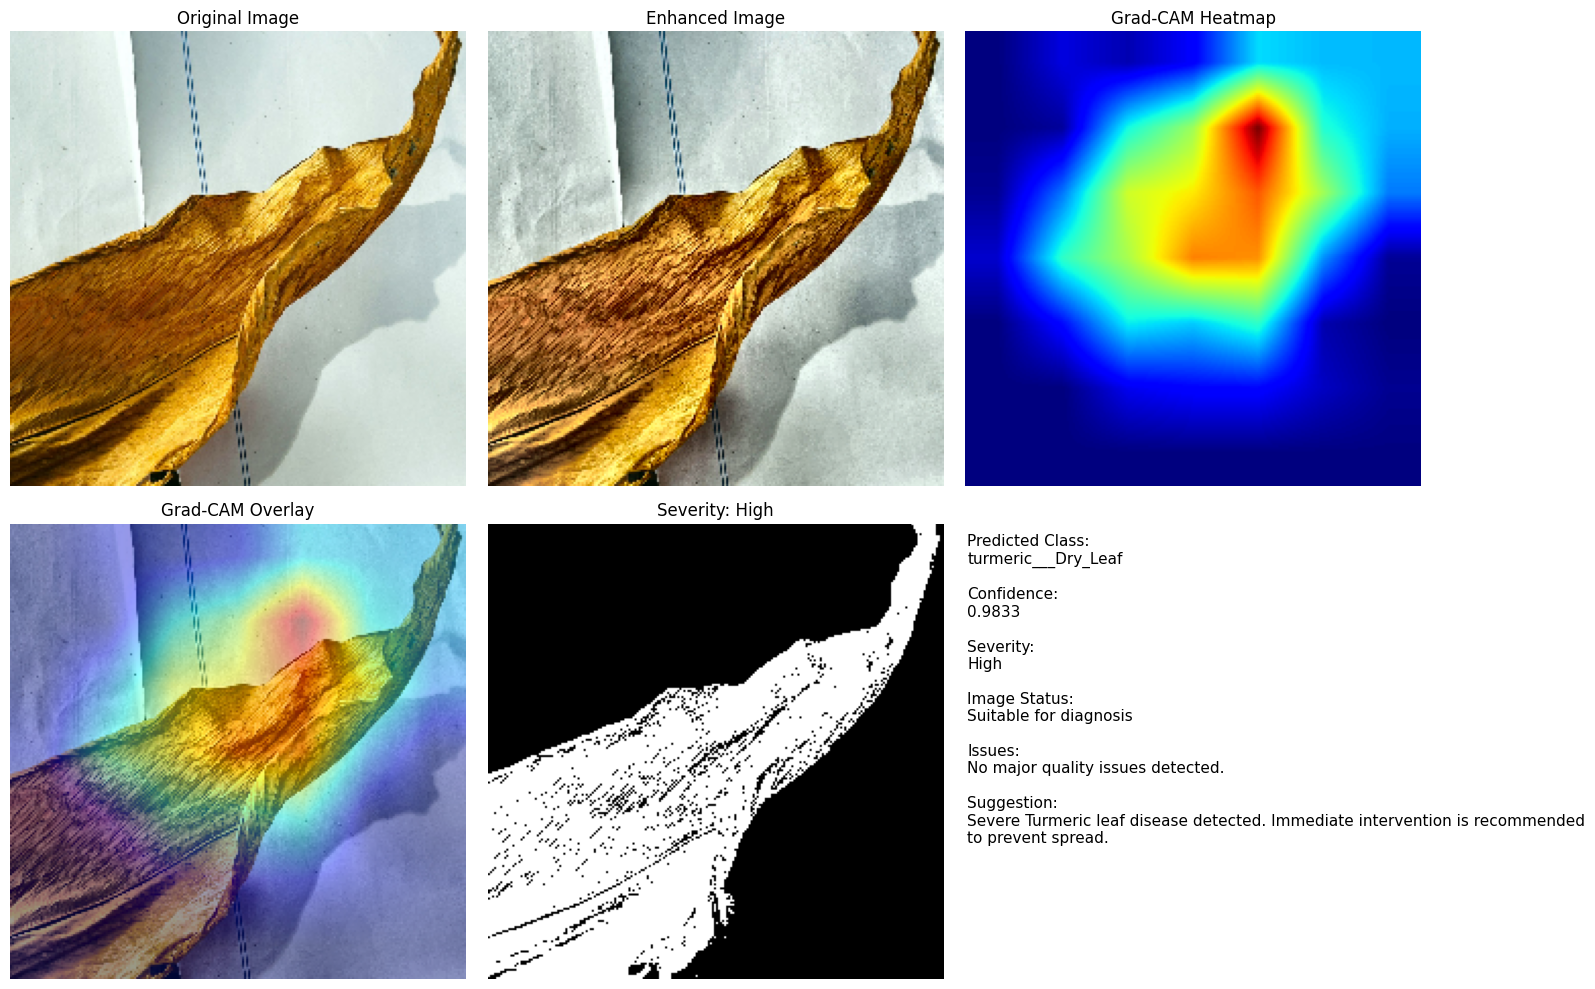

In [ ]:
status, issues, brightness, blur_score = field_support_checks(img, confidence)
suggestion = get_suggestion(predicted_class, confidence, severity)

issues_text = "\n".join([f"- {x}" for x in issues]) if issues else "No major quality issues detected."

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(enhanced)
plt.title("Enhanced Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(overlay_rgb)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(lesion_mask, cmap='gray')
plt.title(f"Severity: {severity}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.text(
    0.02, 0.98,
    f"Predicted Class:\n{predicted_class}\n\n"
    f"Confidence:\n{confidence:.4f}\n\n"
    f"Severity:\n{severity}\n\n"
    f"Image Status:\n{status}\n\n"
    f"Issues:\n{issues_text}\n\n"
    f"Suggestion:\n{suggestion}",
    va='top',
    fontsize=11,
    wrap=True
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
report_text = f"""
====== AYURVEDIC PLANT DIAGNOSIS REPORT ======

Predicted Class : {predicted_class}
Confidence      : {confidence:.4f}
Severity        : {severity}
Image Status    : {status}
Brightness      : {brightness:.2f}
Blur Score      : {blur_score:.2f}

Issues:
{issues_text}

Suggestion:
{suggestion}
"""

print(report_text)


====== AYURVEDIC PLANT DIAGNOSIS REPORT ======

Predicted Class : turmeric___Dry_Leaf
Confidence      : 0.9833
Severity        : High
Image Status    : Suitable for diagnosis
Brightness      : 167.85
Blur Score      : 874.17

Issues:
No major quality issues detected.

Suggestion:
Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread.



In [ ]:
multimodal_report = f"""
====== ADVANCED MULTIMODAL DIAGNOSIS REPORT ======

Predicted Class   : {predicted_class}
Confidence        : {confidence:.4f}
Severity          : {severity}

Leaf Color Statistics:
- Mean Red        : {leaf_stats['mean_red']}
- Mean Green      : {leaf_stats['mean_green']}
- Mean Blue       : {leaf_stats['mean_blue']}
- Mean Hue        : {leaf_stats['mean_hue']}
- Mean Saturation : {leaf_stats['mean_saturation']}
- Mean Value      : {leaf_stats['mean_value']}
- Greenness Index : {leaf_stats['greenness_index']}

Environmental Data:
- Temperature     : {temperature} °C
- Humidity        : {humidity} %
- Soil Moisture   : {soil_moisture} %
- Environment     : {environment_condition}

Environmental Remarks:
- {'; '.join(env_remarks)}

Suggestion:
{suggestion}
"""

print(multimodal_report)


====== ADVANCED MULTIMODAL DIAGNOSIS REPORT ======

Predicted Class   : turmeric___Dry_Leaf
Confidence        : 0.9833
Severity          : High

Leaf Color Statistics:
- Mean Red        : 174.27
- Mean Green      : 161.62
- Mean Blue       : 129.82
- Mean Hue        : 52.24
- Mean Saturation : 95.42
- Mean Value      : 182.48
- Greenness Index : 9.58

Environmental Data:
- Temperature     : 32.5 °C
- Humidity        : 68.0 %
- Soil Moisture   : 42.0 %
- Environment     : Outdoor / Natural Daylight

Environmental Remarks:
- Temperature is within a moderate range.; Humidity is within an acceptable range.; Soil moisture appears balanced.

Suggestion:
Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread.



In [ ]:
def assess_leaf_health_status(predicted_class, confidence, severity):
    if confidence < 0.50:
        return "Uncertain"

    if "healthy" in predicted_class.lower():
        return "Healthy"

    if severity == "Low":
        return "Mildly Affected"
    elif severity == "Medium":
        return "Moderately Affected"
    else:
        return "Severely Affected"

In [ ]:
def assess_color_quality(leaf_stats):
    greenness = leaf_stats["greenness_index"]
    saturation = leaf_stats["mean_saturation"]
    brightness = leaf_stats["mean_value"]

    remarks = []

    if greenness > 20:
        color_quality = "Good"
        remarks.append("Leaf has strong green appearance.")
    elif greenness > 5:
        color_quality = "Moderate"
        remarks.append("Leaf greenness is slightly reduced.")
    else:
        color_quality = "Poor"
        remarks.append("Leaf may show yellowing or browning.")

    if brightness < 70:
        remarks.append("Leaf appears dark or dull.")
    if saturation < 40:
        remarks.append("Leaf color intensity is low.")

    return color_quality, remarks

In [ ]:
leaf_health_status = assess_leaf_health_status(predicted_class, confidence, severity)
color_quality, color_quality_remarks = assess_color_quality(leaf_stats)

print("Leaf Health Status:", leaf_health_status)
print("Leaf Color Quality:", color_quality)
print("Color Remarks:")
for r in color_quality_remarks:
    print("-", r)

Leaf Health Status: Severely Affected
Leaf Color Quality: Moderate
Color Remarks:
- Leaf greenness is slightly reduced.


In [ ]:
print("\n========== FINAL PROJECT OUTPUT ==========")
print(f"Predicted Class      : {predicted_class}")
print(f"Confidence           : {float(confidence):.4f}")
print(f"Leaf Health Status   : {leaf_health_status}")
print(f"Leaf Color Quality   : {color_quality}")
print(f"Severity Level       : {severity}")
print(f"Severity Ratio       : {float(ratio):.4f}")
print(f"Image Status         : {status}")
print(f"Suggestion           : {suggestion}")
print("==========================================")


========== FINAL PROJECT OUTPUT ==========
Predicted Class      : turmeric___Dry_Leaf
Confidence           : 0.9833
Leaf Health Status   : Severely Affected
Leaf Color Quality   : Moderate
Severity Level       : High
Severity Ratio       : 0.3605
Image Status         : Suitable for diagnosis
Suggestion           : Severe Turmeric leaf disease detected. Immediate intervention is recommended to prevent spread.


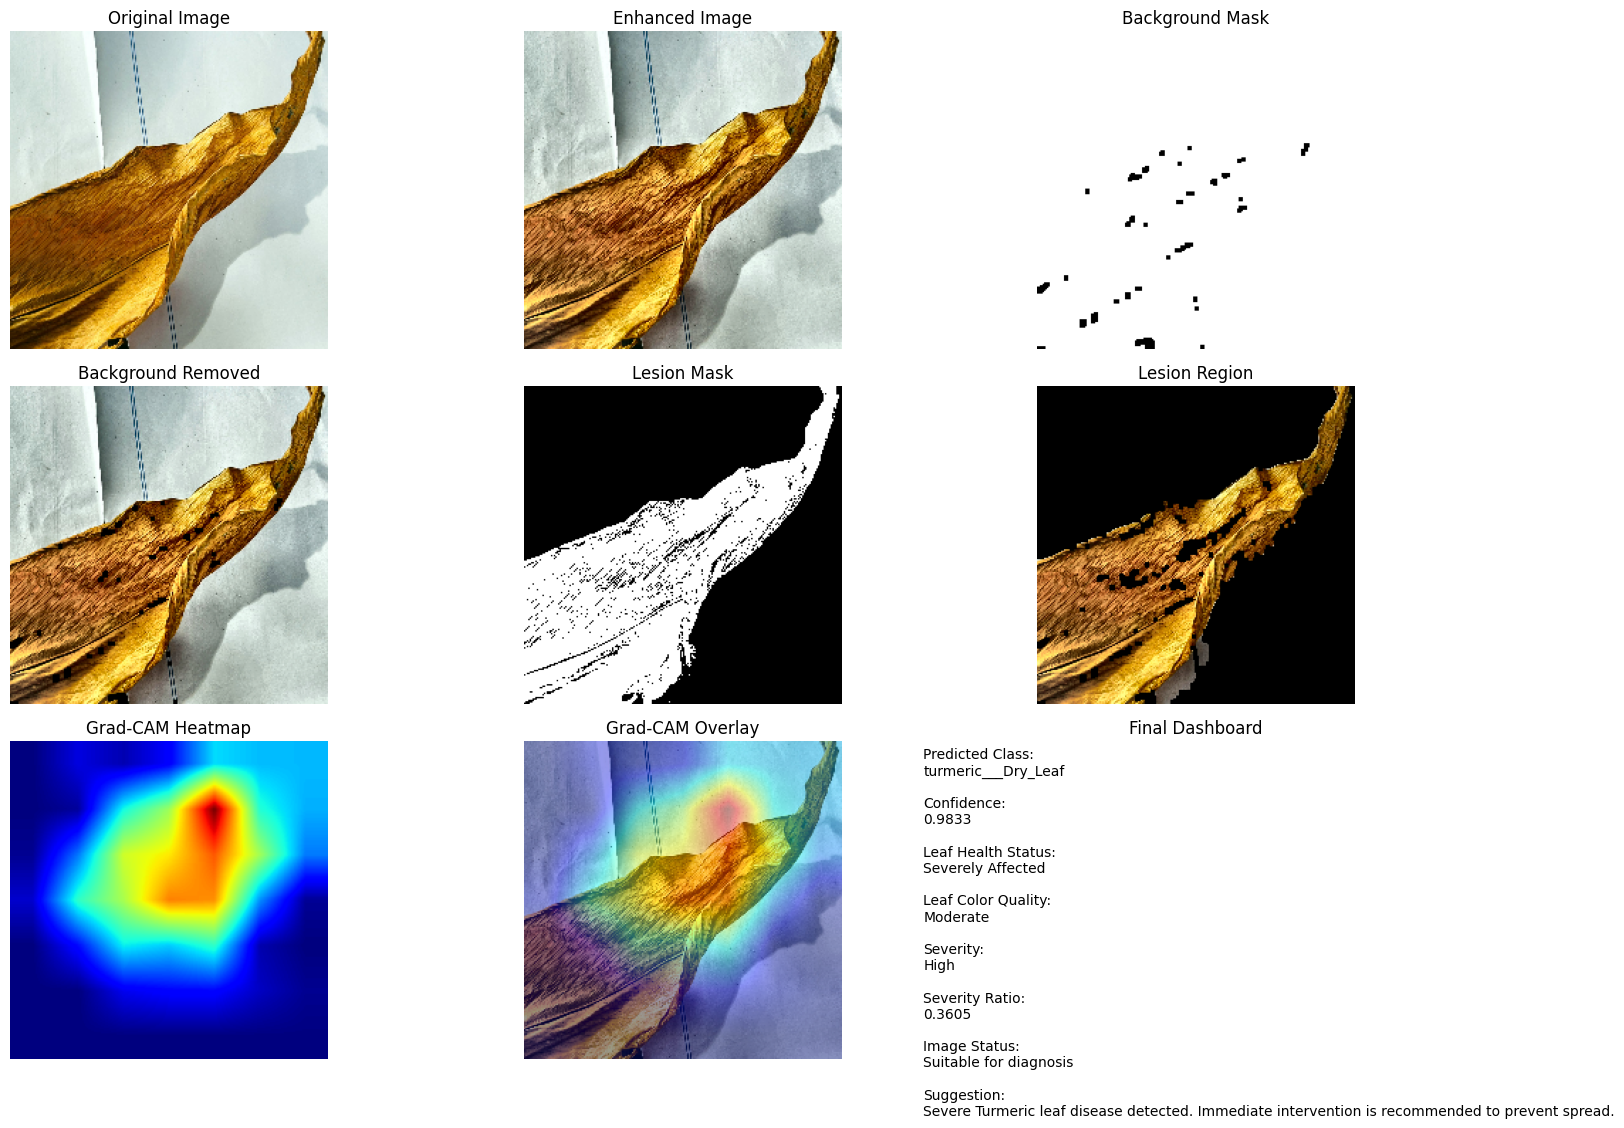

In [ ]:
plt.figure(figsize=(18, 12))

# Row 1
plt.subplot(3, 3, 1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(enhanced)
plt.title("Enhanced Image")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(bg_mask, cmap='gray')
plt.title("Background Mask")
plt.axis("off")

# Row 2
plt.subplot(3, 3, 4)
plt.imshow(bg_removed)
plt.title("Background Removed")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(lesion_mask, cmap='gray')
plt.title("Lesion Mask")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(lesion)
plt.title("Lesion Region")
plt.axis("off")

# Row 3
plt.subplot(3, 3, 7)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(overlay_rgb)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.subplot(3, 3, 9)
plt.text(
    0.02, 0.98,
    f"Predicted Class:\n{predicted_class}\n\n"
    f"Confidence:\n{float(confidence):.4f}\n\n"
    f"Leaf Health Status:\n{leaf_health_status}\n\n"
    f"Leaf Color Quality:\n{color_quality}\n\n"
    f"Severity:\n{severity}\n\n"
    f"Severity Ratio:\n{float(ratio):.4f}\n\n"
    f"Image Status:\n{status}\n\n"
    f"Suggestion:\n{suggestion}",
    va='top',
    fontsize=10,
    wrap=True
)
plt.title("Final Dashboard")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

final_report_data = {
    "Predicted Class": [predicted_class],
    "Confidence": [round(float(confidence), 4)],
    "Leaf Health Status": [leaf_health_status],
    "Leaf Color Quality": [color_quality],
    "Severity Level": [severity],
    "Severity Ratio": [round(float(ratio), 4)],
    "Temperature (C)": [temperature],
    "Humidity (%)": [humidity],
    "Soil Moisture (%)": [soil_moisture],
    "Image Status": [status],
    "Suggestion": [suggestion]
}

report_df = pd.DataFrame(final_report_data)

excel_path = "/content/final_plant_diagnosis_report.xlsx"
report_df.to_excel(excel_path, index=False)

print("Excel report saved at:", excel_path)
report_df

Excel report saved at: /content/final_plant_diagnosis_report.xlsx


,Predicted Class,Confidence,Leaf Health Status,Leaf Color Quality,Severity Level,Severity Ratio,Temperature (C),Humidity (%),Soil Moisture (%),Image Status,Suggestion
0,turmeric___Dry_Leaf,0.9833,Severely Affected,Moderate,High,0.3605,32.5,68.0,42.0,Suitable for diagnosis,Severe Turmeric leaf disease detected. Immedia...


In [ ]:
from google.colab import files
files.download("/content/final_plant_diagnosis_report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>